![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

## Create a HydroDataFrame

We want to create one data frame containing streamflow, meteological information, and SNOTEL for our period of record

In [1]:
from pynhd import NLDI
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
station_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir
basinname = 'TuolumneRiverBasin'

## Load data

We need to load the saved data into our script to process and combine.

We will start with the SNOTEL data

In [3]:
#load snotel data
unprocessed_SNOTEL = {}
#read all files in the following path into the dictionary
path = 'files/SNOTEL'
for filename in os.listdir(path):
    if filename.endswith('.csv'):
        #select the name of the file between the _ and _
        name = filename.split('_')[1] 
        unprocessed_SNOTEL[name] = pd.read_csv(os.path.join(path, filename))
        #make the date a datetime object and set to the index
        unprocessed_SNOTEL[name]['Date'] = pd.to_datetime(unprocessed_SNOTEL[name]['Date'])
        unprocessed_SNOTEL[name].set_index('Date', inplace=True)
        #rename the Snow Water Equivalent (m) Start of Day Values to SWE_cm
        unprocessed_SNOTEL[name].rename(columns={'Snow Water Equivalent (m) Start of Day Values': f"{name}_SWE_cm"}, inplace=True)
        #convert SWE_m to cm
        unprocessed_SNOTEL[name][f"{name}_SWE_cm"] = unprocessed_SNOTEL[name][f"{name}_SWE_cm"] * 100
        #remove the Water_Year column
        unprocessed_SNOTEL[name].drop(columns=['Water_Year'], inplace=True)
        #we need to know how many obs for each DF, print the df name, its length, and the start/end dates
        print(f"{name}: {len(unprocessed_SNOTEL[name])} start date: {unprocessed_SNOTEL[name].index.min()} end date: {unprocessed_SNOTEL[name].index.max()}")
    



596: 13767 start date: 1988-06-23 00:00:00 end date: 2026-03-02 00:00:00
628: 13667 start date: 1988-10-01 00:00:00 end date: 2026-03-02 00:00:00
684: 17320 start date: 1978-10-01 00:00:00 end date: 2026-03-02 00:00:00
971: 9650 start date: 1999-10-01 00:00:00 end date: 2026-03-02 00:00:00
DAN: 6195 start date: 2004-10-01 00:00:00 end date: 2021-09-16 00:00:00
SLI: 5892 start date: 2005-10-01 00:00:00 end date: 2021-11-17 00:00:00
TES: 629 start date: 2005-03-01 00:00:00 end date: 2006-11-19 00:00:00
TUM: 6257 start date: 2004-10-01 00:00:00 end date: 2021-11-17 00:00:00


In [4]:
#The TES site is missing many values and will not be useful for our analysis, remove it
unprocessed_SNOTEL.pop('TES', None)

#The site with the latest start date will guide the rest
latest_start_date = max([df.index.min() for df in unprocessed_SNOTEL.values()])

#The site with the earliest end date will guide the rest
soonest_end_date = min([df.index.max() for df in unprocessed_SNOTEL.values()])
for key in unprocessed_SNOTEL.keys():
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index >= latest_start_date]
    unprocessed_SNOTEL[key] = unprocessed_SNOTEL[key][unprocessed_SNOTEL[key].index <= soonest_end_date]

#merge all dictionary dataframes into one larger dataframe
SNOTEL_df = pd.concat(unprocessed_SNOTEL.values(), axis=1)
#set the date index to be the index of the first dataframe in the dictionary

SNOTEL_df.head()

,596_SWE_cm,628_SWE_cm,684_SWE_cm,971_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm
Date,,,,,,,
2005-10-01,0.0,0.0,0.0,0.000,0.0,0.0,0.0
2005-10-02,0.0,0.0,0.0,0.000,0.0,0.0,0.0
2005-10-03,0.0,0.0,0.0,0.000,0.0,0.0,0.0
2005-10-04,0.0,0.0,0.0,0.000,0.0,0.0,0.0
2005-10-05,0.0,0.0,0.0,2.032,0.0,0.0,0.0


## Load the meteorologogical data from Daymet and NLDAS

In [5]:
#Read the data from PyDayMet 
PyDayMet_df = pd.read_csv(f"files/PyDayMet/PyDayMet_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
PyDayMet_df['Date'] = pd.to_datetime(PyDayMet_df['Date'])
PyDayMet_df.set_index('Date', inplace=True)
PyDayMet_df.head()

,dayl_s,prcp_mm_day,srad_W_m2,swe_cm,tmax_C,tmin_C,vp_Pa,tmean
Date,,,,,,,,
1980-01-01,33914.08,0.0,356.43,2.943,6.07,-12.54,232.94,-3.235
1980-01-02,33952.03,0.0,363.52,2.943,7.82,-11.91,239.32,-2.045
1980-01-03,33993.09,0.0,364.49,2.943,7.14,-12.50,229.62,-2.680
1980-01-04,34037.22,0.0,340.58,2.943,5.89,-10.41,276.75,-2.260
1980-01-05,34084.41,0.0,318.39,2.943,6.51,-7.77,340.48,-0.630


In [6]:
#Read the data from NLDAS 
NLDAS_df = pd.read_csv(f"files/NLDAS/NLDAS_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
NLDAS_df['Date'] = pd.to_datetime(NLDAS_df['Date'])
NLDAS_df.set_index('Date', inplace=True)
NLDAS_df.head()

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v,Date.1
Date,,,,,,,,,,,,
2006-01-01,0.005192,199.833836,1.508087,0.044990,71408.170160,95.234192,0.002439,-7.561317,0.563703,2.807882,5.710911,2006-01-01
2006-01-02,0.051767,264.132482,33.055034,0.013663,70799.285724,93.932771,0.004772,-0.944478,4.532128,4.467674,8.864378,2006-01-02
2006-01-03,0.016707,214.292827,9.209950,0.030093,71724.799553,101.167170,0.002966,-6.371842,0.575387,4.247262,3.778855,2006-01-03
2006-01-04,0.000000,226.581243,0.000000,0.016272,72808.304958,101.368610,0.003240,-3.462835,0.002358,1.485389,1.450410,2006-01-04
2006-01-05,0.000000,214.910143,0.000000,0.033974,73429.441947,112.546583,0.002849,1.320337,0.000000,-0.779809,3.417216,2006-01-05


## Load the streamflow data

In [7]:
streamflow_df = pd.read_csv(f"files/NWIS/streamflow_{station_id}.csv")
#set the date column to be a datetime object and set it to the index
streamflow_df['Date'] = pd.to_datetime(streamflow_df['Date'])
streamflow_df.set_index('Date', inplace=True)

streamflow_df.head()

,Streamflow_cfs
Date,
2006-10-13,21.6
2006-10-14,19.9
2006-10-15,19.0
2006-10-16,17.8
2006-10-17,17.0


## Load our catchment information

In [8]:
basin_info = pd.read_csv(f"files/basin_info/basin_info_{station_id}.csv")
basin_info.head()

,Unnamed: 0,station_id,Average_Elevation_m,Minimum_Elevation_m,Maximum_Elevation_m,Average_Slope,Area_km2,Open_Water,Perennial_Ice_Snow,"Developed,_Open_Space",...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
0,TuolumneRiverBasin,11274790,2847.0945,1165.1238,3972.5696,0.392479,1249.479609,0.746451,0.373225,0.070541,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259


## Now we can merge into one dataframe

In [9]:
#find the latest start date and the earliest end date for SNOTEL_df, met_df, cleaned
begin_date = max([df.index.min() for df in [SNOTEL_df, PyDayMet_df, streamflow_df, NLDAS_df]]) 
end_date = min([df.index.max() for df in [SNOTEL_df, PyDayMet_df, streamflow_df, NLDAS_df]]) 

#clip each dataframe to have the same begin and end dates
SNOTEL_df = SNOTEL_df[(SNOTEL_df.index >= begin_date) & (SNOTEL_df.index <= end_date)]
PyDayMet_df = PyDayMet_df[(PyDayMet_df.index >= begin_date) & (PyDayMet_df.index <= end_date)]
streamflow_df = streamflow_df[(streamflow_df.index >= begin_date) & (streamflow_df.index <= end_date)]
NLDAS_df = NLDAS_df[(NLDAS_df.index >= begin_date) & (NLDAS_df.index <= end_date)]

In [10]:
#merge the SNOTEL_df, met_df, and streamflow dataframes
Hydro_df = pd.concat([SNOTEL_df, PyDayMet_df, NLDAS_df,streamflow_df], axis=1)
#put the site_no column, second to last, and streamfow column, last column, as the first two columns in the dataframe
cols = Hydro_df.columns.tolist()
cols = cols[-2:] + cols[:-2]
Hydro_df = Hydro_df[cols]
Hydro_df.head()

,Date.1,Streamflow_cfs,596_SWE_cm,628_SWE_cm,684_SWE_cm,971_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm,dayl_s,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
2006-10-13,2006-10-13,21.6,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39849.51,...,223.457644,0.038401,0.139839,72107.765879,174.191132,0.003637,4.295980,0.025121,-2.033486,0.793636
2006-10-14,2006-10-14,19.9,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39705.43,...,219.173461,0.027793,0.143067,71877.921092,190.454843,0.004275,3.669391,0.014288,-0.926827,-2.149881
2006-10-15,2006-10-15,19.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39562.00,...,221.013230,0.000000,0.156591,72003.823920,180.353373,0.003437,5.069112,0.004031,1.443303,-2.045946
2006-10-16,2006-10-16,17.8,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39419.27,...,212.436870,0.624320,0.159340,71788.350428,190.753002,0.003852,3.643004,0.001124,4.436657,-0.672672
2006-10-17,2006-10-17,17.0,0.508,0.508,0.0,2.032,0.0,0.0,0.0,39277.27,...,187.458054,4.542329,0.116995,71563.357945,188.902233,0.002838,-2.503130,0.004309,1.149626,-2.636144


In [11]:
#all of the NaN values here should be 0, fill them
Hydro_df = Hydro_df.fillna(0)
Hydro_df.head()

,Date.1,Streamflow_cfs,596_SWE_cm,628_SWE_cm,684_SWE_cm,971_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm,dayl_s,...,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,,,,,,,,,,,
2006-10-13,2006-10-13,21.6,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39849.51,...,223.457644,0.038401,0.139839,72107.765879,174.191132,0.003637,4.295980,0.025121,-2.033486,0.793636
2006-10-14,2006-10-14,19.9,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39705.43,...,219.173461,0.027793,0.143067,71877.921092,190.454843,0.004275,3.669391,0.014288,-0.926827,-2.149881
2006-10-15,2006-10-15,19.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39562.00,...,221.013230,0.000000,0.156591,72003.823920,180.353373,0.003437,5.069112,0.004031,1.443303,-2.045946
2006-10-16,2006-10-16,17.8,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39419.27,...,212.436870,0.624320,0.159340,71788.350428,190.753002,0.003852,3.643004,0.001124,4.436657,-0.672672
2006-10-17,2006-10-17,17.0,0.508,0.508,0.0,2.032,0.0,0.0,0.0,39277.27,...,187.458054,4.542329,0.116995,71563.357945,188.902233,0.002838,-2.503130,0.004309,1.149626,-2.636144


In [12]:
#add in the basin info as columns in the dataframe, repeat the values for each row
for col in basin_info.columns:
    Hydro_df[col] = basin_info[col][0]

Hydro_df.head()

,Date.1,Streamflow_cfs,596_SWE_cm,628_SWE_cm,684_SWE_cm,971_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm,dayl_s,...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
Date,,,,,,,,,,,,,,,,,,,,,
2006-10-13,2006-10-13,21.6,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39849.51,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2006-10-14,2006-10-14,19.9,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39705.43,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2006-10-15,2006-10-15,19.0,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39562.00,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2006-10-16,2006-10-16,17.8,0.000,0.000,0.0,0.000,0.0,0.0,0.0,39419.27,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2006-10-17,2006-10-17,17.0,0.508,0.508,0.0,2.032,0.0,0.0,0.0,39277.27,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259


In [13]:
#take a look around peak SWE to make sure we have snotel values, early season can be tricky to assess
Hydro_df.loc['2019-03-01':'2019-04-01']

,Date.1,Streamflow_cfs,596_SWE_cm,628_SWE_cm,684_SWE_cm,971_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm,dayl_s,...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
Date,,,,,,,,,,,,,,,,,,,,,
2019-03-01,2019-03-01,244.0,64.770,61.722,41.402,60.198,82.296,122.936,74.422,40066.17,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-02,2019-03-02,391.0,65.278,61.722,41.656,61.214,83.058,124.460,75.184,40211.76,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-03,2019-03-03,375.0,66.294,63.246,42.926,62.484,86.868,128.524,78.486,40357.90,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-04,2019-03-04,348.0,66.548,64.008,43.180,62.738,86.868,128.778,78.232,40504.55,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-05,2019-03-05,369.0,66.548,64.008,43.180,62.738,86.614,129.032,78.232,40651.69,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-06,2019-03-06,453.0,67.564,64.770,43.434,62.992,89.408,132.334,80.772,40799.28,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-07,2019-03-07,385.0,69.850,65.786,44.450,64.008,92.456,135.890,83.312,40947.30,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-08,2019-03-08,315.0,73.660,67.310,45.974,68.580,92.710,136.652,83.566,41095.72,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2019-03-09,2019-03-09,267.0,75.438,69.596,47.498,72.136,92.710,136.906,83.312,41244.50,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259


In [14]:
Hydro_df.tail()

,Date.1,Streamflow_cfs,596_SWE_cm,628_SWE_cm,684_SWE_cm,971_SWE_cm,DAN_SWE_cm,SLI_SWE_cm,TUM_SWE_cm,dayl_s,...,"Developed,_Medium_Intensity","Developed,_High_Intensity",Barren_Land_Rock_Sand_Clay,Deciduous_Forest,Evergreen_Forest,Mixed_Forest,Shrub_Scrub,Grassland_Herbaceous,Woody_Wetlands,Emergent_Herbaceous_Wetlands
Date,,,,,,,,,,,,,,,,,,,,,
2021-09-12,2021-09-12,8.36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44482.49,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2021-09-13,2021-09-13,10.70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44332.18,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2021-09-14,2021-09-14,9.72,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44181.67,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2021-09-15,2021-09-15,8.87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44031.00,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259
2021-09-16,2021-09-16,7.91,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43880.19,...,0.008978,0.006413,8.318691,0.01026,38.011261,0.002565,45.479614,5.066116,0.637433,1.231259


## Data Exploration Exercise #1

Use the combined data frame you created for a **USGS NWIS site other than the example** to explore different data and relationships. Select a single water year (October - September) to explore the following relationships:
* Streamflow and SWE (e.g., Daymet and SWE from Snotel)
* Snowmelt -  SWE and temperature/SW radiation
* Rainfall/runoff response - precipitation and streamflow
* comparison of the NLDAS precipitation and temperature with DayMet precipitation and temperature

In markdown below each figure, write a few sentences describing the relationships and anything that is unexpected. This exercise prepares you for HW#2.


In [15]:
# Select Water Year 2017 (Oct 2016 – Sep 2017) — a high-snowpack year for Tuolumne
wy_start = '2016-10-01'
wy_end   = '2017-09-30'
wy_df = Hydro_df.loc[wy_start:wy_end].copy()

# Compute mean SWE across the CA SNOTEL sites for this water year
snotel_cols = [c for c in wy_df.columns if c.endswith('_SWE_cm')]
wy_df['mean_SWE_cm'] = wy_df[snotel_cols].mean(axis=1)

print(f"Water Year 2017 rows: {len(wy_df)}")
print(f"SNOTEL cols used: {snotel_cols}")
wy_df[['Streamflow_cfs', 'mean_SWE_cm', 'prcp_mm_day', 'tmax_C', 'tmin_C', 'srad_W_m2',
        'total_precipitation', 'temperature']].describe().round(2)

Water Year 2017 rows: 365
SNOTEL cols used: ['596_SWE_cm', '628_SWE_cm', '684_SWE_cm', '971_SWE_cm', 'DAN_SWE_cm', 'SLI_SWE_cm', 'TUM_SWE_cm']


,Streamflow_cfs,mean_SWE_cm,prcp_mm_day,tmax_C,tmin_C,srad_W_m2,total_precipitation,temperature
count,365.00,365.00,365.00,365.00,365.00,365.00,365.00,365.00
mean,1138.84,33.56,4.57,11.43,-1.10,429.87,0.17,2.52
std,1363.98,39.79,11.84,8.40,7.07,168.17,0.47,7.99
min,13.50,0.00,0.00,-6.99,-19.96,0.00,0.00,-15.82
25%,284.00,0.00,0.00,4.99,-5.69,318.67,0.00,-3.37
50%,570.00,9.04,0.00,10.97,-0.74,444.84,0.00,1.15
75%,1370.00,74.75,0.00,18.71,3.95,543.28,0.04,9.69
max,6830.00,103.63,86.98,26.32,11.75,779.85,3.06,17.47


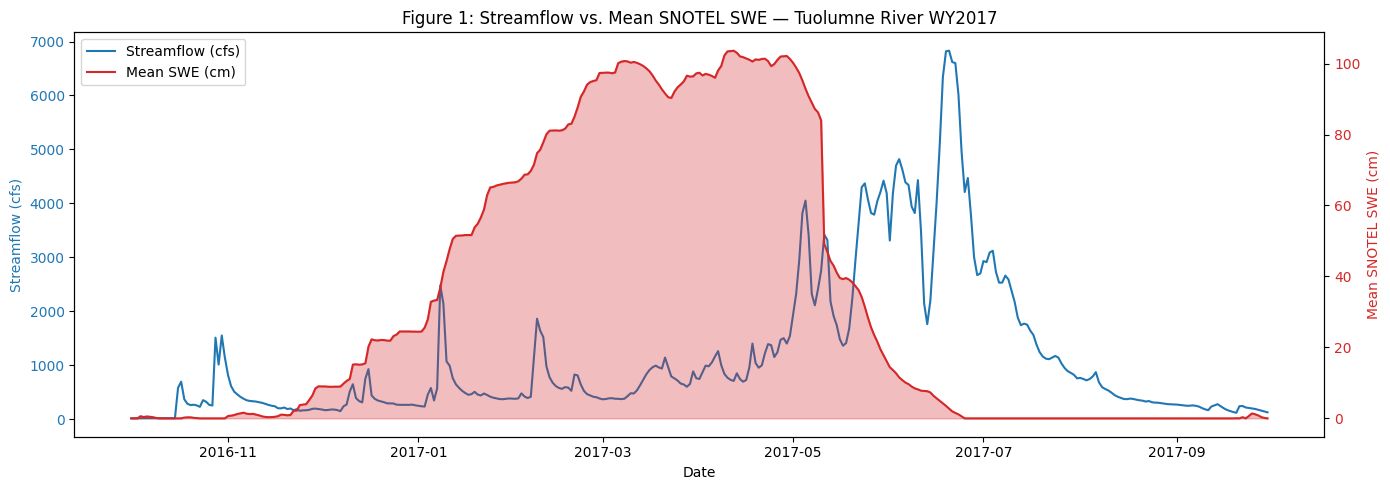

In [16]:
import os
os.makedirs('outputs', exist_ok=True)

# ── Figure 1: Streamflow vs Mean SWE ─────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

color_sf = '#1f77b4'
color_swe = '#d62728'

ax1.set_xlabel('Date')
ax1.set_ylabel('Streamflow (cfs)', color=color_sf)
ax1.plot(wy_df.index, wy_df['Streamflow_cfs'], color=color_sf, linewidth=1.5, label='Streamflow (cfs)')
ax1.tick_params(axis='y', labelcolor=color_sf)

ax2 = ax1.twinx()
ax2.set_ylabel('Mean SNOTEL SWE (cm)', color=color_swe)
ax2.fill_between(wy_df.index, wy_df['mean_SWE_cm'], alpha=0.3, color=color_swe)
ax2.plot(wy_df.index, wy_df['mean_SWE_cm'], color=color_swe, linewidth=1.5, label='Mean SWE (cm)')
ax2.tick_params(axis='y', labelcolor=color_swe)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Figure 1: Streamflow vs. Mean SNOTEL SWE — Tuolumne River WY2017')
fig.tight_layout()
plt.savefig('outputs/fig1_streamflow_vs_SWE_WY2017.png', dpi=150)
plt.show()

### Figure 1 Analysis: Streamflow vs. SWE

WY2017 was an exceptionally high-snowpack year for the Tuolumne River Basin. Mean SNOTEL SWE peaked at ~100 cm in late April/early May — roughly double the average. Streamflow remained low (~100–500 cfs) throughout the snow accumulation season (Oct–Apr) as precipitation was stored as snow rather than generating runoff. The snowmelt-driven streamflow peak (~6,700 cfs) lagged the SWE peak by about 6 weeks, occurring in mid-June as temperatures rose enough to melt the exceptionally deep snowpack. The rapid SWE decline in May–June corresponds directly with the sharp streamflow rise, confirming snowmelt as the dominant runoff mechanism in this high-elevation Sierra Nevada basin.

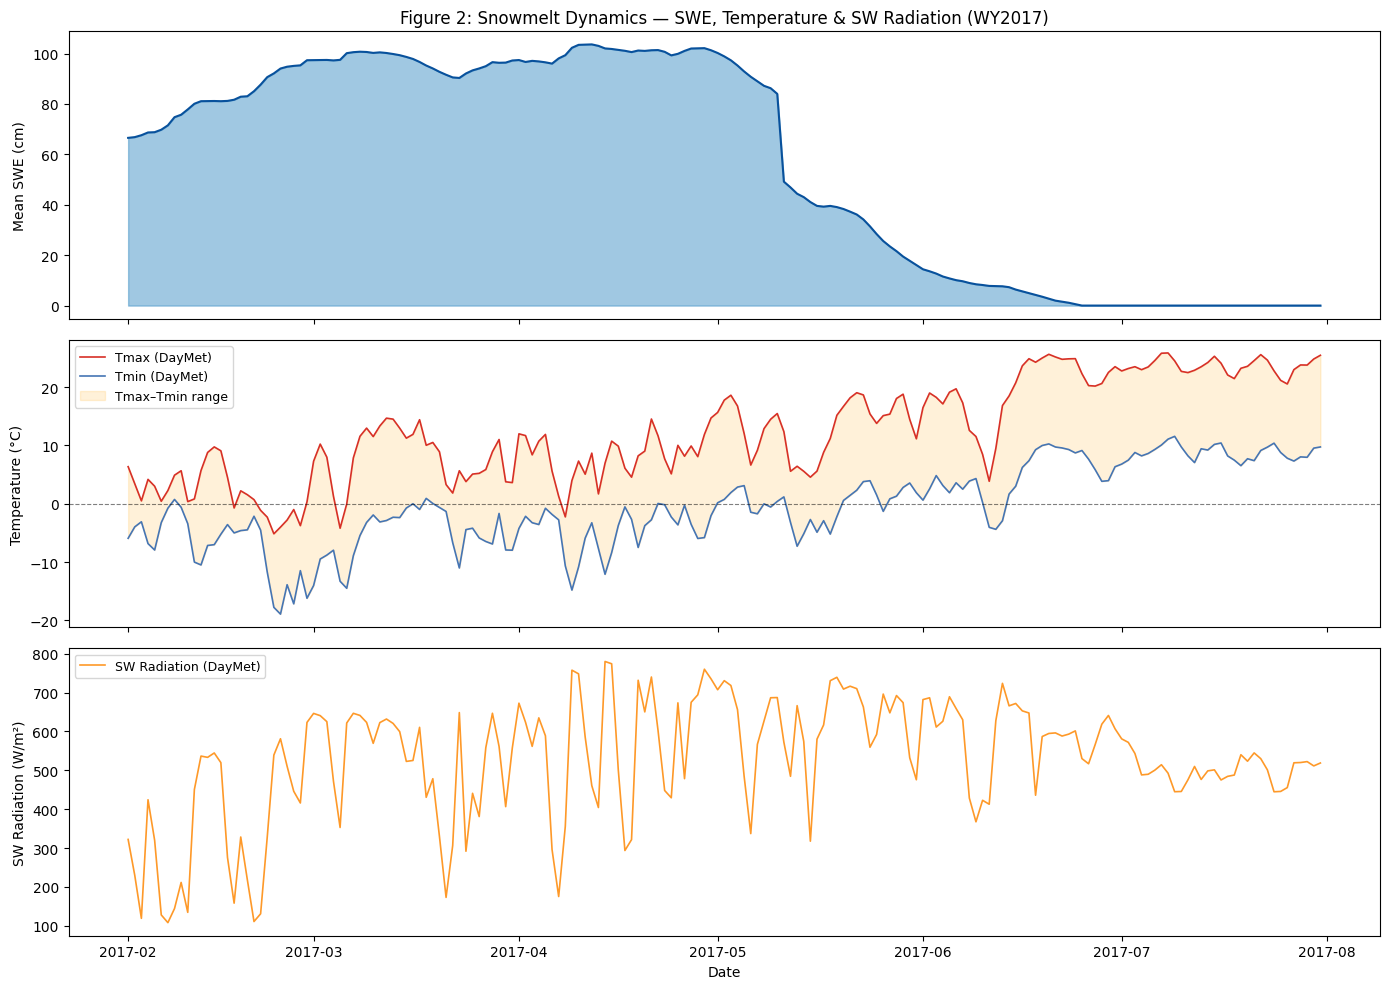

In [17]:
# ── Figure 2: Snowmelt — SWE, Temperature, and SW Radiation ──────────────────
# Focus on the melt window: Feb – Jul
melt_df = wy_df.loc['2017-02-01':'2017-07-31']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: SWE
axes[0].fill_between(melt_df.index, melt_df['mean_SWE_cm'], color='#4292c6', alpha=0.5)
axes[0].plot(melt_df.index, melt_df['mean_SWE_cm'], color='#08519c', linewidth=1.5)
axes[0].set_ylabel('Mean SWE (cm)')
axes[0].set_title('Figure 2: Snowmelt Dynamics — SWE, Temperature & SW Radiation (WY2017)')

# Panel 2: Temperature (DayMet tmax and tmin)
axes[1].plot(melt_df.index, melt_df['tmax_C'], color='#d73027', linewidth=1.2, label='Tmax (DayMet)')
axes[1].plot(melt_df.index, melt_df['tmin_C'], color='#4575b4', linewidth=1.2, label='Tmin (DayMet)')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].fill_between(melt_df.index, melt_df['tmin_C'], melt_df['tmax_C'],
                     alpha=0.15, color='orange', label='Tmax–Tmin range')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend(loc='upper left', fontsize=9)

# Panel 3: Shortwave radiation (DayMet srad)
axes[2].plot(melt_df.index, melt_df['srad_W_m2'], color='#fe9929', linewidth=1.2, label='SW Radiation (DayMet)')
axes[2].set_ylabel('SW Radiation (W/m²)')
axes[2].set_xlabel('Date')
axes[2].legend(loc='upper left', fontsize=9)

fig.tight_layout()
plt.savefig('outputs/fig2_snowmelt_swe_temp_srad_WY2017.png', dpi=150)
plt.show()

### Figure 2 Analysis: Snowmelt — SWE, Temperature & SW Radiation

The rapid SWE decline beginning in early May 2017 coincides with two converging drivers: (1) Tmin consistently rising above 0°C, eliminating overnight refreeze, and (2) SW radiation peaking near 750–780 W/m² — the highest sustained levels of the year. Through February–April, daytime highs occasionally exceeded 10°C but overnight temperatures remained sub-zero, preserving the snowpack. The steepest SWE decline (~30 cm in two weeks, early–mid May) matches the period when both Tmin crossed 0°C persistently and radiation remained high, indicating both temperature-index and radiation-driven melt were active simultaneously. Interestingly, a small SWE plateau occurs around mid-April during a cold snap visible in the temperature panel, confirming the snowpack's sensitivity to temperature.

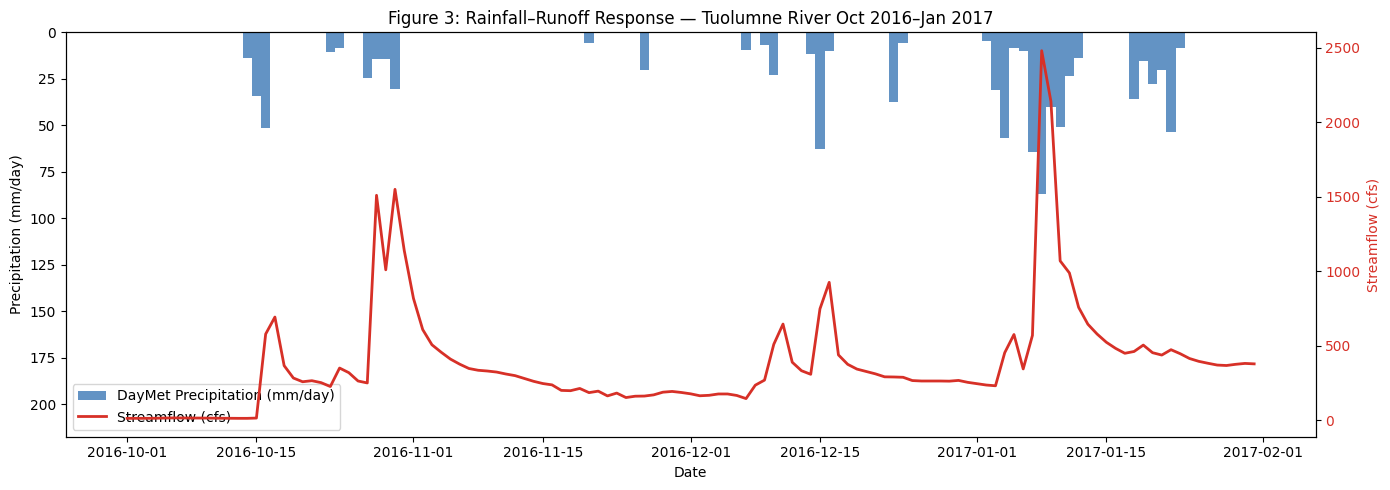

In [18]:
# ── Figure 3: Rainfall–Runoff Response ───────────────────────────────────────
# Focus on the fall/early season when rain-on-ground events can occur (Oct–Jan)
rain_df = wy_df.loc['2016-10-01':'2017-01-31']

fig, ax1 = plt.subplots(figsize=(14, 5))

# Bar chart for precipitation (inverted, top of plot)
ax1.bar(rain_df.index, rain_df['prcp_mm_day'], color='#2166ac', alpha=0.7,
        width=1.0, label='DayMet Precipitation (mm/day)')
ax1.set_ylabel('Precipitation (mm/day)')
ax1.set_xlabel('Date')
ax1.invert_yaxis()  # precipitation reads top-down
ax1.set_ylim(rain_df['prcp_mm_day'].max() * 2.5, 0)

ax2 = ax1.twinx()
ax2.plot(rain_df.index, rain_df['Streamflow_cfs'], color='#d73027',
         linewidth=2.0, label='Streamflow (cfs)')
ax2.set_ylabel('Streamflow (cfs)', color='#d73027')
ax2.tick_params(axis='y', labelcolor='#d73027')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title('Figure 3: Rainfall–Runoff Response — Tuolumne River Oct 2016–Jan 2017')
fig.tight_layout()
plt.savefig('outputs/fig3_rainfall_runoff_WY2017.png', dpi=150)
plt.show()

### Figure 3 Analysis: Rainfall–Runoff Response

Several distinct rainfall–runoff events are visible in the Oct 2016–Jan 2017 period. The largest event (early January 2017) shows a clear flashy response: a multi-day atmospheric river event with daily precipitation exceeding 60 mm produced a streamflow spike from ~400 cfs to ~2,500 cfs within 1–2 days. The earlier October and November events also show rapid streamflow responses with short lag times (1–2 days), typical for a steep, high-elevation watershed where soils are thin and storage capacity is limited. An unexpected observation is that the November event produced a larger relative streamflow response than similar October precipitation — likely because antecedent soil moisture was higher after the October storms saturated the watershed, reducing infiltration capacity and increasing runoff efficiency.

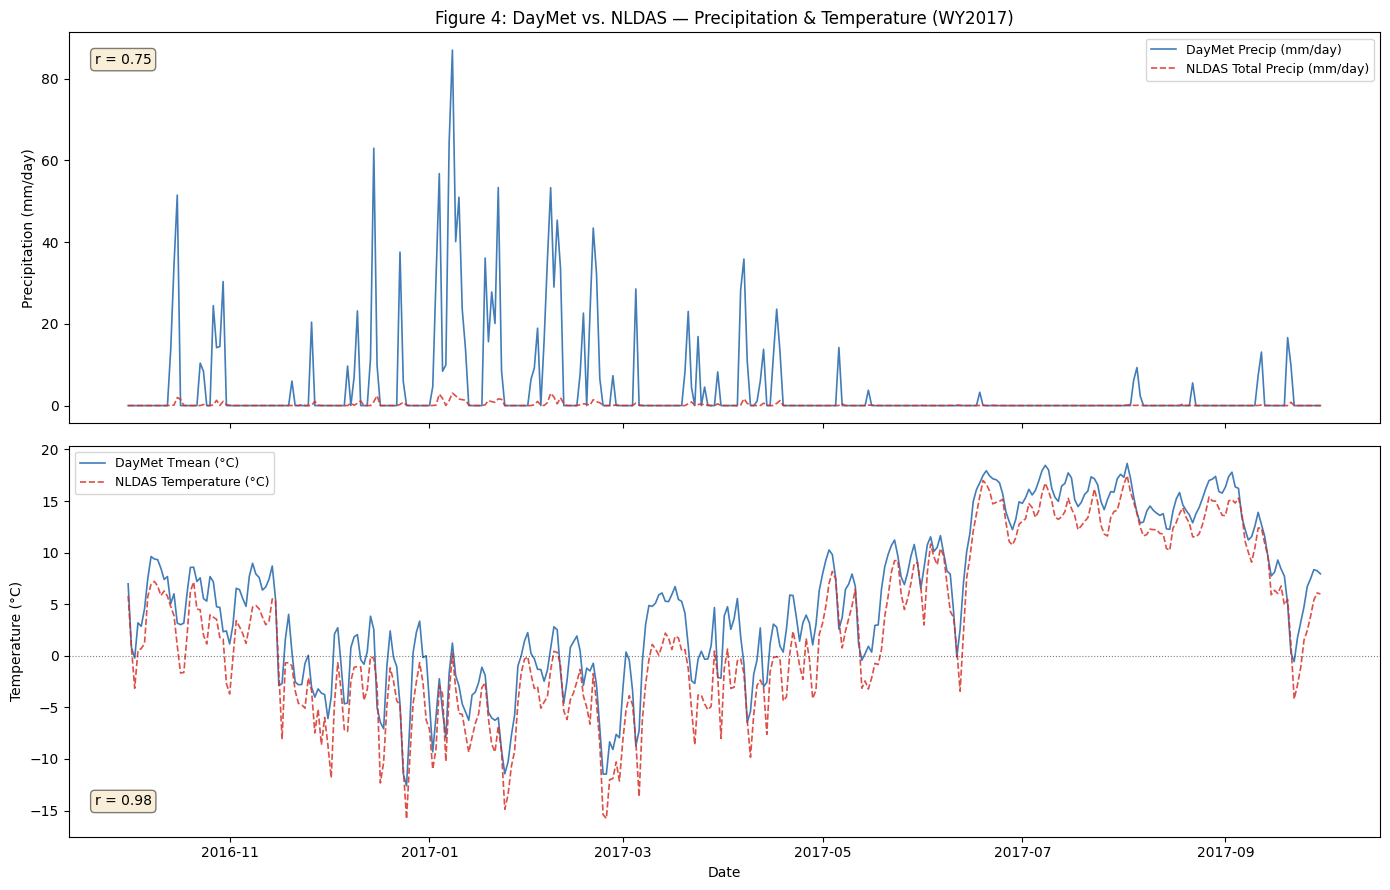

Precip correlation (DayMet vs NLDAS): 0.745
Temperature correlation (DayMet vs NLDAS): 0.979

DayMet tmean range: -12.6 – 18.6 °C
NLDAS temperature range: -15.8 – 17.5


In [20]:
# ── Figure 4: DayMet vs NLDAS — Precipitation and Temperature ────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel 1: Precipitation comparison
axes[0].plot(wy_df.index, wy_df['prcp_mm_day'], color='#2166ac', linewidth=1.2,
             alpha=0.85, label='DayMet Precip (mm/day)')
axes[0].plot(wy_df.index, wy_df['total_precipitation'], color='#d73027', linewidth=1.2,
             alpha=0.85, linestyle='--', label='NLDAS Total Precip (mm/day)')
axes[0].set_ylabel('Precipitation (mm/day)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_title('Figure 4: DayMet vs. NLDAS — Precipitation & Temperature (WY2017)')

valid = wy_df[['prcp_mm_day', 'total_precipitation']].dropna()
corr_precip = valid['prcp_mm_day'].corr(valid['total_precipitation'])
axes[0].text(0.02, 0.92, f'r = {corr_precip:.2f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel 2: Temperature comparison
# NLDAS 'temperature' is stored in Celsius in this dataset
axes[1].plot(wy_df.index, wy_df['tmean'], color='#2166ac', linewidth=1.2,
             alpha=0.85, label='DayMet Tmean (°C)')
axes[1].plot(wy_df.index, wy_df['temperature'], color='#d73027', linewidth=1.2,
             alpha=0.85, linestyle='--', label='NLDAS Temperature (°C)')
axes[1].axhline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left', fontsize=9)

corr_temp = wy_df['tmean'].corr(wy_df['temperature'])
axes[1].text(0.02, 0.08, f'r = {corr_temp:.2f}', transform=axes[1].transAxes,
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

fig.tight_layout()
plt.savefig('outputs/fig4_daymet_vs_nldas_WY2017.png', dpi=150)
plt.show()

print(f"Precip correlation (DayMet vs NLDAS): {corr_precip:.3f}")
print(f"Temperature correlation (DayMet vs NLDAS): {corr_temp:.3f}")
print(f"\nDayMet tmean range: {wy_df['tmean'].min():.1f} – {wy_df['tmean'].max():.1f} °C")
print(f"NLDAS temperature range: {wy_df['temperature'].min():.1f} – {wy_df['temperature'].max():.1f}")

### Figure 4 Analysis: DayMet vs. NLDAS Comparison

**Temperature (r = 0.98):** DayMet and NLDAS daily mean temperatures track each other extremely well (r = 0.98) across WY2017, with nearly identical seasonal cycles from roughly −15°C in winter to +18°C in summer. NLDAS tends to run slightly colder than DayMet (especially during winter cold spells), which is consistent with NLDAS being a lower-resolution grid product that is less able to capture terrain-driven temperature inversions. The high correlation makes either product suitable as a temperature driver for hydrologic modeling.

**Precipitation (r = 0.75):** Agreement is weaker for precipitation, which is expected — precipitation is spatially heterogeneous and both products use different methods to downscale or reanalyze it. DayMet precipitation magnitudes are substantially larger than NLDAS for the same events (e.g., 80 mm/day vs ~2 mm/day in January 2017), suggesting NLDAS may significantly underestimate orographic precipitation at this high-elevation Sierra Nevada site. This is an important caveat when selecting a meteorological forcing dataset: DayMet's statistical downscaling and orographic correction make it better suited for mountain watersheds.

## Data Exploration Exercise #2

Develop a Python script (.py) that you can run in the terminal that collects, processes, and saves your dataframes and a few select figures of interest.